# Clean CY Models

Fit Carreau-Yasuda curves to the slurry measurements and build a row-level physics dataset for downstream modelling.

## 1. Import Libraries

Load the core libraries used for fitting the CY model and handling warnings.

In [1]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
import warnings

# Suppress convergence warnings from the non-linear optimizer
warnings.filterwarnings("ignore")

## 2. Load Data

Read the expanded slurry dataset and check the available columns.

In [2]:
df = pd.read_csv('../data/processed/combined_slurry_data_expanded.csv')

print(f"Rows: {len(df)}  |  Unique formulations (Composite_Mix_ID): {df['Composite_Mix_ID'].nunique()}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Rows: 178  |  Unique formulations (Composite_Mix_ID): 68
Columns: ['Dispersent_Type', 'Solid_Content_pct', 'Solid_Additive_pct', 'Viscosity_at_shear_rate_1_1/s', 'Viscosity_at_shear_rate_10_1/s', 'Viscosity_at_shear_rate_100_1/s', 'Source_Batch', 'Composite_Mix_ID', 'NMC_pct', 'C65_pct', 'KS6L_pct', 'PVDF_pct']


,Dispersent_Type,Solid_Content_pct,Solid_Additive_pct,Viscosity_at_shear_rate_1_1/s,Viscosity_at_shear_rate_10_1/s,Viscosity_at_shear_rate_100_1/s,Source_Batch,Composite_Mix_ID,NMC_pct,C65_pct,KS6L_pct,PVDF_pct
0,Hypermer,73.0,0.50,10.56640,3.78921,1.99755,Batch_1,F1_Hypermer_73.0_0.5,96.0,2.0,0.0,2.0
1,Hypermer,73.0,0.25,71.65190,14.08460,4.82515,Batch_1,F1_Hypermer_73.0_0.25,96.0,2.0,0.0,2.0
2,Hypermer,73.0,0.25,9.64639,3.26827,1.61720,Batch_1,F1_Hypermer_73.0_0.25,96.0,2.0,0.0,2.0
3,Hypermer,77.0,0.25,61.11070,18.77450,7.51220,Batch_1,F1_Hypermer_77.0_0.25,96.0,2.0,0.0,2.0
4,Hypermer,73.0,0.25,8.37111,4.83186,2.30422,Batch_1,F1_Hypermer_73.0_0.25,96.0,2.0,0.0,2.0


## 3. Define the CY Model (shared)

Define the Carreau-Yasuda viscosity function used for fitting. This is shared across train and test.

In [3]:
def carreau_yasuda(shear_rate, eta_0, eta_inf, lambda_time, n, a):
    """
    Carreau-Yasuda viscosity model.

    Parameters
    ----------
    shear_rate   : array-like  — applied shear rate (1/s)
    eta_0        : float       — zero-shear viscosity (Pa·s)
    eta_inf      : float       — infinite-shear viscosity (Pa·s)
    lambda_time  : float       — relaxation time (s); inverse of critical shear rate
    n            : float       — power-law index (< 1 = shear thinning)
    a            : float       — Yasuda parameter (transition width)
    """
    return eta_inf + (eta_0 - eta_inf) * (1 + (lambda_time * shear_rate)**a)**((n - 1) / a)

## 4. Set Up Columns

Define shear-rate and viscosity targets, then add physics-informed chemistry ratio features used by the ML models.

In [4]:
shear_rates = np.array([1.0, 10.0, 100.0])

target_cols = [
    'Viscosity_at_shear_rate_1_1/s',
    'Viscosity_at_shear_rate_10_1/s',
    'Viscosity_at_shear_rate_100_1/s',
]

# Physics-informed feature engineering (computed before any train/test split)
eps = 1e-8
df['Solid_to_Liquid_Ratio'] = df['Solid_Content_pct'] / (100.0 - df['Solid_Content_pct'] + eps)
df['Binder_to_Active_Ratio'] = df['PVDF_pct'] / (df['NMC_pct'] + df['C65_pct'] + eps)

# Input features to carry into the final ML-ready physics dataset
input_cols = [
    'Dispersent_Type', 'Solid_Content_pct', 'Solid_Additive_pct',
    'NMC_pct', 'C65_pct', 'KS6L_pct', 'PVDF_pct', 'Source_Batch',
    'Solid_to_Liquid_Ratio', 'Binder_to_Active_Ratio',
]

print("Target columns:", target_cols)
print("Input columns: ", input_cols)
print("\nEngineered feature preview:")
display(df[['Solid_Content_pct', 'PVDF_pct', 'NMC_pct', 'C65_pct', 'Solid_to_Liquid_Ratio', 'Binder_to_Active_Ratio']].head())

Target columns: ['Viscosity_at_shear_rate_1_1/s', 'Viscosity_at_shear_rate_10_1/s', 'Viscosity_at_shear_rate_100_1/s']
Input columns:  ['Dispersent_Type', 'Solid_Content_pct', 'Solid_Additive_pct', 'NMC_pct', 'C65_pct', 'KS6L_pct', 'PVDF_pct', 'Source_Batch', 'Solid_to_Liquid_Ratio', 'Binder_to_Active_Ratio']

Engineered feature preview:


,Solid_Content_pct,PVDF_pct,NMC_pct,C65_pct,Solid_to_Liquid_Ratio,Binder_to_Active_Ratio
0,73.0,2.0,96.0,2.0,2.703704,0.020408
1,73.0,2.0,96.0,2.0,2.703704,0.020408
2,73.0,2.0,96.0,2.0,2.703704,0.020408
3,77.0,2.0,96.0,2.0,3.347826,0.020408
4,73.0,2.0,96.0,2.0,2.703704,0.020408


## 5. Fit CY Parameters on Entire Dataset

Set `USE_LOCKED_PARAMETER_ABLATION = True` to fix $a=2.0$ and $\eta_\infty=0.01$; set it to `False` to fit all five CY parameters. Fit the model per row on the entire dataset and evaluate using n-sample error metrics on the full observed shear-rate set.

In [5]:
from scipy.optimize import least_squares
from sklearn.metrics import r2_score

# Toggle this flag to switch between the ablation and the full CY fit
USE_LOCKED_PARAMETER_ABLATION = True

# Ablation settings used only when USE_LOCKED_PARAMETER_ABLATION is True
LOCKED_ETA_INF = 0.01
LOCKED_A = 2.0

# Robust CY-label fitting upgrades for lambda stability
USE_LOG_RESIDUALS_FOR_CY_FIT = True
FIT_LOG_LAMBDA = True
LOG_LAMBDA_BOUNDS = (-3.0, 3.0)  # lambda in [exp(-3), exp(3)] ~ [0.05, 20.1]
RESIDUAL_EPS = 1e-8

cy_dataset = []
failed_fits = []

if USE_LOCKED_PARAMETER_ABLATION:
    def fit_row_cy_model(x_values, y_values, initial_guess_free, bounds_free, reg_weight=1e-2):
        """Fit CY with eta_inf and a fixed; optimize [eta_0, lambda_time/log_lambda, n]."""
        def residuals(theta_free):
            eta_0 = theta_free[0]
            if FIT_LOG_LAMBDA:
                lambda_time = np.exp(theta_free[1])
                n = theta_free[2]
            else:
                lambda_time = theta_free[1]
                n = theta_free[2]

            y_hat = carreau_yasuda(x_values, eta_0, LOCKED_ETA_INF, lambda_time, n, LOCKED_A)

            if USE_LOG_RESIDUALS_FOR_CY_FIT:
                data_resid = np.log(y_values + RESIDUAL_EPS) - np.log(y_hat + RESIDUAL_EPS)
            else:
                data_resid = y_values - y_hat

            reg_resid = np.sqrt(reg_weight) * (theta_free - initial_guess_free)
            return np.concatenate([data_resid, reg_resid])

        return least_squares(residuals, x0=initial_guess_free, bounds=bounds_free, max_nfev=20000)
else:
    def fit_row_cy_model(x_values, y_values, initial_guess, bounds, reg_weight=1e-2):
        """Fit the full CY model with all five parameters free."""
        def residuals(theta):
            eta_0 = theta[0]
            eta_inf = theta[1]
            lambda_time = np.exp(theta[2]) if FIT_LOG_LAMBDA else theta[2]
            n = theta[3]
            a = theta[4]

            y_hat = carreau_yasuda(x_values, eta_0, eta_inf, lambda_time, n, a)

            if USE_LOG_RESIDUALS_FOR_CY_FIT:
                data_resid = np.log(y_values + RESIDUAL_EPS) - np.log(y_hat + RESIDUAL_EPS)
            else:
                data_resid = y_values - y_hat

            reg_resid = np.sqrt(reg_weight) * (theta - initial_guess)
            return np.concatenate([data_resid, reg_resid])

        return least_squares(residuals, x0=initial_guess, bounds=bounds, max_nfev=20000)

mode_label = "locked a=2.0, eta_inf=0.01" if USE_LOCKED_PARAMETER_ABLATION else "full 5-parameter fit"
print(f"CY fit mode: {mode_label}")
print(f"Log residuals: {USE_LOG_RESIDUALS_FOR_CY_FIT} | Fit log(lambda): {FIT_LOG_LAMBDA} | log(lambda) bounds: {LOG_LAMBDA_BOUNDS}")
print(f"Fitting CY parameters for {len(df)} rows (entire dataset)...\n")

for row_idx, raw_row in df.iterrows():
    x_data = shear_rates.astype(float)
    y_data = raw_row[target_cols].values.astype(float)

    try:
        if USE_LOCKED_PARAMETER_ABLATION:
            if FIT_LOG_LAMBDA:
                # Free transformed parameters: [eta_0, log_lambda_time, n]
                initial_guess_free = np.array([np.max(y_data), np.log(1.0), 0.5], dtype=float)
                bounds_free = (
                    np.array([0.1, LOG_LAMBDA_BOUNDS[0], 0.1], dtype=float),
                    np.array([np.inf, LOG_LAMBDA_BOUNDS[1], 1.0], dtype=float),
                )
            else:
                initial_guess_free = np.array([np.max(y_data), 1.0, 0.5], dtype=float)
                bounds_free = (
                    np.array([0.1, 0.001, 0.1], dtype=float),
                    np.array([np.inf, 100.0, 1.0], dtype=float),
                )

            final_fit = fit_row_cy_model(x_data, y_data, initial_guess_free, bounds_free)
            eta_0 = final_fit.x[0]
            lambda_time = np.exp(final_fit.x[1]) if FIT_LOG_LAMBDA else final_fit.x[1]
            n = final_fit.x[2]
            eta_inf = LOCKED_ETA_INF
            a = LOCKED_A
        else:
            if FIT_LOG_LAMBDA:
                initial_guess = np.array([np.max(y_data), np.min(y_data), np.log(1.0), 0.5, 2.0], dtype=float)
                bounds = (
                    np.array([0.1, 0.01, LOG_LAMBDA_BOUNDS[0], 0.1, 0.1], dtype=float),
                    np.array([np.inf, np.max(y_data) + 50.0, LOG_LAMBDA_BOUNDS[1], 1.0, 10.0], dtype=float),
                )
            else:
                initial_guess = np.array([np.max(y_data), np.min(y_data), 1.0, 0.5, 2.0], dtype=float)
                bounds = (
                    np.array([0.1, 0.01, 0.001, 0.1, 0.1], dtype=float),
                    np.array([np.inf, np.max(y_data) + 50.0, 100.0, 1.0, 10.0], dtype=float),
                )

            final_fit = fit_row_cy_model(x_data, y_data, initial_guess, bounds)
            eta_0 = final_fit.x[0]
            eta_inf = final_fit.x[1]
            lambda_time = np.exp(final_fit.x[2]) if FIT_LOG_LAMBDA else final_fit.x[2]
            n = final_fit.x[3]
            a = final_fit.x[4]

        y_pred_all = carreau_yasuda(x_data, eta_0, eta_inf, lambda_time, n, a)
        n_rmse = np.sqrt(np.mean((y_data - y_pred_all) ** 2))
        n_r2 = r2_score(y_data, y_pred_all)
        n_mae = np.mean(np.abs(y_data - y_pred_all))

        record = raw_row[input_cols].to_dict()
        record['row_index'] = row_idx
        record['Composite_Mix_ID'] = raw_row['Composite_Mix_ID']
        record['eta_0'] = eta_0
        record['eta_inf'] = eta_inf
        record['lambda_time'] = lambda_time
        record['n'] = n
        record['a'] = a
        record['CY_N_RMSE'] = n_rmse
        record['CY_N_R2'] = n_r2
        record['CY_N_MAE'] = n_mae

        cy_dataset.append(record)
    except Exception:
        failed_fits.append(row_idx)

print(f"Successful fits : {len(cy_dataset)}")
print(f"Failed fits     : {len(failed_fits)}" + (f"  -> first failed rows: {failed_fits[:10]}" if failed_fits else ""))

CY fit mode: locked a=2.0, eta_inf=0.01
Log residuals: True | Fit log(lambda): True | log(lambda) bounds: (-3.0, 3.0)
Fitting CY parameters for 178 rows (entire dataset)...

Successful fits : 178
Failed fits     : 0


## 6. Build Physics Dataset

Collect the per-row CY fits and their n-sample fit metrics into a dataframe for downstream modeling.

In [6]:
physics_df = pd.DataFrame(cy_dataset)

# Approximate pooled/hierarchical stabilization for lambda labels
USE_FORMULATION_LAMBDA_SHRINKAGE = True
LAMBDA_SHRINKAGE_WEIGHT = 0.30  # 0=no pooling, 1=full formulation mean

if USE_FORMULATION_LAMBDA_SHRINKAGE and 'lambda_time' in physics_df.columns:
    physics_df['lambda_time_raw'] = physics_df['lambda_time']
    formulation_lambda_mean = physics_df.groupby('Composite_Mix_ID')['lambda_time'].transform('mean')
    physics_df['lambda_time'] = (
        (1.0 - LAMBDA_SHRINKAGE_WEIGHT) * physics_df['lambda_time']
        + LAMBDA_SHRINKAGE_WEIGHT * formulation_lambda_mean
    )

# Confidence proxy for weighted ML training (higher confidence = lower fit RMSE)
physics_df['lambda_confidence'] = 1.0 / (physics_df['CY_N_RMSE'] + 1e-6)

print(f"Physics dataset shape: {physics_df.shape}")
print(f"Unique formulations: {physics_df['Composite_Mix_ID'].nunique()}")
if USE_FORMULATION_LAMBDA_SHRINKAGE:
    print(f"Lambda shrinkage applied: weight={LAMBDA_SHRINKAGE_WEIGHT:.2f}")
print("\nCY parameter and n-sample fit summary:")
display(physics_df[['eta_0', 'eta_inf', 'lambda_time', 'n', 'a', 'CY_N_RMSE', 'CY_N_R2', 'CY_N_MAE']].describe().round(4))

print("\nPhysics dataset preview:")
display(physics_df.head())

Physics dataset shape: (178, 22)
Unique formulations: 68
Lambda shrinkage applied: weight=0.30

CY parameter and n-sample fit summary:


,eta_0,eta_inf,lambda_time,n,a,CY_N_RMSE,CY_N_R2,CY_N_MAE
count,178.0000,178.00,178.0000,178.0000,178.0,178.0000,178.0000,178.0000
mean,53.0869,0.01,0.9922,0.5697,2.0,5.7604,0.9527,3.9999
std,66.1017,0.00,0.1900,0.1765,0.0,8.4983,0.0372,5.7102
min,1.1651,0.01,0.4579,0.1000,2.0,0.0081,0.8392,0.0075
25%,6.1971,0.01,0.8835,0.4211,2.0,0.1761,0.9235,0.1343
50%,23.9585,0.01,0.9851,0.5869,2.0,1.8866,0.9573,1.4675
75%,72.6663,0.01,1.1042,0.6963,2.0,8.4548,0.9881,5.9139
max,324.7339,0.01,1.5052,0.9133,2.0,43.9271,0.9998,29.1942



Physics dataset preview:


,Dispersent_Type,Solid_Content_pct,Solid_Additive_pct,NMC_pct,C65_pct,KS6L_pct,PVDF_pct,Source_Batch,Solid_to_Liquid_Ratio,Binder_to_Active_Ratio,...,eta_0,eta_inf,lambda_time,n,a,CY_N_RMSE,CY_N_R2,CY_N_MAE,lambda_time_raw,lambda_confidence
0,Hypermer,73.0,0.50,96.0,2.0,0.0,2.0,Batch_1,2.703704,0.020408,...,10.983380,0.01,1.206293,0.629852,2.0,0.803254,0.952622,0.655236,1.201290,1.244935
1,Hypermer,73.0,0.25,96.0,2.0,0.0,2.0,Batch_1,2.703704,0.020408,...,71.794475,0.01,1.039070,0.402265,2.0,8.556573,0.916225,6.056591,1.066575,0.116869
2,Hypermer,73.0,0.25,96.0,2.0,0.0,2.0,Batch_1,2.703704,0.020408,...,10.116113,0.01,1.127360,0.602138,2.0,0.733608,0.955099,0.588815,1.192704,1.363124
3,Hypermer,77.0,0.25,96.0,2.0,0.0,2.0,Batch_1,3.347826,0.020408,...,61.238678,0.01,0.950988,0.527904,2.0,5.071627,0.951692,3.726268,0.946289,0.197175
4,Hypermer,73.0,0.25,96.0,2.0,0.0,2.0,Batch_1,2.703704,0.020408,...,8.687730,0.01,0.758245,0.684670,2.0,0.105779,0.998193,0.083599,0.665396,9.453627


## 6.1 CY Fit Summary

Quick summary of per-row CY fit quality using n-sample metrics.

In [7]:
summary_stats = physics_df[[
    'CY_N_RMSE',
    'CY_N_R2',
    'CY_N_MAE',
]].agg(['mean', 'std', 'median']).round(4)

print("Summary of CY n-sample fit accuracy (entire dataset):")
display(summary_stats)

print(f"Mean n-sample R2   : {physics_df['CY_N_R2'].mean():.4f}")
print(f"Mean n-sample RMSE : {physics_df['CY_N_RMSE'].mean():.4f}")
print(f"Mean n-sample MAE  : {physics_df['CY_N_MAE'].mean():.4f}")

Summary of CY n-sample fit accuracy (entire dataset):


,CY_N_RMSE,CY_N_R2,CY_N_MAE
mean,5.7604,0.9527,3.9999
std,8.4983,0.0372,5.7102
median,1.8866,0.9573,1.4675


Mean n-sample R2   : 0.9527
Mean n-sample RMSE : 5.7604
Mean n-sample MAE  : 3.9999


## 7. Train-Test Split for ML Modeling

Split the physics dataset into train and test for ML model training and evaluation.

In [8]:
from sklearn.model_selection import train_test_split

# Split by formulation IDs first to avoid leakage, then map back to rows
unique_formulations = physics_df['Composite_Mix_ID'].dropna().unique()
form_train, form_test = train_test_split(
    unique_formulations,
    test_size=0.2,
    random_state=42,
    shuffle=True,
)

physics_train = physics_df[physics_df['Composite_Mix_ID'].isin(form_train)].copy()
physics_test = physics_df[physics_df['Composite_Mix_ID'].isin(form_test)].copy()

train_forms = set(physics_train['Composite_Mix_ID'].unique())
test_forms = set(physics_test['Composite_Mix_ID'].unique())
overlap_forms = train_forms & test_forms

print(f"Train set: {len(physics_train)} rows  |  {len(train_forms)} formulations")
print(f"Test set : {len(physics_test)} rows  |  {len(test_forms)} formulations")
print(f"Formulation overlap (must be 0): {len(overlap_forms)}")

if overlap_forms:
    print(f"Overlapping formulations: {sorted(list(overlap_forms))[:10]}")
else:
    print("No formulation leakage detected.")

print("\nTrain physics features ready for ML model training.")
print("Test physics features will be used for final model evaluation.")

Train set: 136 rows  |  54 formulations
Test set : 42 rows  |  14 formulations
Formulation overlap (must be 0): 0
No formulation leakage detected.

Train physics features ready for ML model training.
Test physics features will be used for final model evaluation.


## 7.1 Repeated K-Fold Summary of CY n-Sample Fit Metrics

Summarize n-sample CY fit metrics across repeated k-fold splits as a robustness check before ML modeling.

In [9]:
from sklearn.model_selection import RepeatedKFold

# Repeated k-fold summary of n-sample CY fit metrics
rkf = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)

cv_fold_metrics = []

for fold_idx, (train_idx, test_idx) in enumerate(rkf.split(physics_df)):
    fold_train = physics_df.iloc[train_idx]
    fold_test = physics_df.iloc[test_idx]

    train_n_r2_mean = fold_train['CY_N_R2'].mean()
    train_n_rmse_mean = fold_train['CY_N_RMSE'].mean()

    test_n_r2_mean = fold_test['CY_N_R2'].mean()
    test_n_rmse_mean = fold_test['CY_N_RMSE'].mean()

    cv_fold_metrics.append({
        'Fold': fold_idx + 1,
        'Train_N_R2': train_n_r2_mean,
        'Train_N_RMSE': train_n_rmse_mean,
        'Test_N_R2': test_n_r2_mean,
        'Test_N_RMSE': test_n_rmse_mean,
    })

cv_fold_df = pd.DataFrame(cv_fold_metrics)

print("Repeated K-Fold Summary of CY n-sample Metrics (5 splits x 3 repeats):")
display(cv_fold_df.round(4))

print(f"\nOverall (across all folds):")
print(f"  Mean n-sample R2   : {cv_fold_df['Test_N_R2'].mean():.4f} ± {cv_fold_df['Test_N_R2'].std():.4f}")
print(f"  Mean n-sample RMSE : {cv_fold_df['Test_N_RMSE'].mean():.4f} ± {cv_fold_df['Test_N_RMSE'].std():.4f}")

Repeated K-Fold Summary of CY n-sample Metrics (5 splits x 3 repeats):


,Fold,Train_N_R2,Train_N_RMSE,Test_N_R2,Test_N_RMSE
0,1,0.9508,6.3724,0.9602,3.3465
1,2,0.9531,5.9010,0.9513,5.2058
2,3,0.9534,4.9647,0.9499,8.8988
3,4,0.9549,5.4348,0.9439,7.0906
4,5,0.9514,6.1287,0.9583,4.2554
5,6,0.9536,5.4404,0.9491,7.0227
6,7,0.9524,5.7847,0.9541,5.6643
7,8,0.9526,5.7040,0.9532,5.9828
8,9,0.9509,5.8908,0.9601,5.2277
9,10,0.9541,5.9796,0.9471,4.8647



Overall (across all folds):
  Mean n-sample R2   : 0.9527 ± 0.0055
  Mean n-sample RMSE : 5.7533 ± 1.4762


## 8. ML Model Training

Train machine learning models (GPR, Random Forest, Extra Trees) to predict CY parameters from composition features using log-transformed targets, then invert predictions back to original scale for evaluation.

In [10]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C, WhiteKernel
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Set up ML-ready features
ml_feature_cols = input_cols  # Composition features

# Exclude fixed CY parameters only when the ablation flag is on
candidate_target_cols = ['eta_0', 'eta_inf', 'lambda_time', 'n', 'a']
if USE_LOCKED_PARAMETER_ABLATION:
    locked_target_cols = [c for c in candidate_target_cols if physics_df[c].nunique(dropna=False) <= 1]
else:
    locked_target_cols = []
ml_target_cols = [c for c in candidate_target_cols if c not in locked_target_cols]

X_train = physics_train[ml_feature_cols]
X_test = physics_test[ml_feature_cols]

# Keep raw targets for evaluation; train on log-transformed targets
y_train_raw = physics_train[ml_target_cols].copy()
y_test_raw = physics_test[ml_target_cols].copy()

TARGET_LOG_EPS = 1e-8
y_train_model = np.log(y_train_raw.clip(lower=TARGET_LOG_EPS))

# Physics-informed GPR kernel settings
GPR_MATERN_NU = 2.5

# Confidence-weighted training: confidence derived from CY fit RMSE proxy
sample_weight_train = physics_train['lambda_confidence'].copy()
sample_weight_train = sample_weight_train / sample_weight_train.mean()
sample_weight_train = sample_weight_train.clip(lower=0.25, upper=4.0)

# For GPR, pass per-sample noise alpha (inverse relation to confidence)
sample_noise_train = 1e-4 / sample_weight_train.values

print(f"ML training set: {X_train.shape}")
print(f"ML test set:     {X_test.shape}")
print(f"\nFeatures: {ml_feature_cols}")
print(f"Targets used for R2 evaluation: {ml_target_cols}")
if locked_target_cols:
    print(f"Locked targets excluded from R2 evaluation: {locked_target_cols}")
else:
    print("No locked targets excluded from R2 evaluation.")
print("Target transform: natural log (train) with exp inverse (eval)")
print(f"GPR kernel: Matern(nu={GPR_MATERN_NU}) + WhiteKernel")
print(f"Sample-weight range: [{sample_weight_train.min():.3f}, {sample_weight_train.max():.3f}]")

# Encode categorical features (Dispersent_Type, Source_Batch)
X_train_encoded = pd.get_dummies(X_train, columns=['Dispersent_Type', 'Source_Batch'], drop_first=False)
X_test_encoded = pd.get_dummies(X_test, columns=['Dispersent_Type', 'Source_Batch'], drop_first=False)

# Align columns between train and test (in case test is missing a category)
missing_cols = set(X_train_encoded.columns) - set(X_test_encoded.columns)
for col in missing_cols:
    X_test_encoded[col] = 0
X_test_encoded = X_test_encoded[X_train_encoded.columns]

# Fill any remaining NaN values with the column mean
X_train_encoded = X_train_encoded.fillna(X_train_encoded.mean())
X_test_encoded = X_test_encoded.fillna(X_train_encoded.mean())

print(f"\nEncoded feature count: {X_train_encoded.shape[1]}")
print(f"Train NaN count: {X_train_encoded.isna().sum().sum()}")
print(f"Test NaN count: {X_test_encoded.isna().sum().sum()}")

# Standardize features for GPR
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

print(f"Train scaled NaN count: {np.isnan(X_train_scaled).sum()}")
print(f"Test scaled NaN count: {np.isnan(X_test_scaled).sum()}")

print("\nML models ready for training.")

ML training set: (136, 10)
ML test set:     (42, 10)

Features: ['Dispersent_Type', 'Solid_Content_pct', 'Solid_Additive_pct', 'NMC_pct', 'C65_pct', 'KS6L_pct', 'PVDF_pct', 'Source_Batch', 'Solid_to_Liquid_Ratio', 'Binder_to_Active_Ratio']
Targets used for R2 evaluation: ['eta_0', 'lambda_time', 'n']
Locked targets excluded from R2 evaluation: ['eta_inf', 'a']
Target transform: natural log (train) with exp inverse (eval)
GPR kernel: Matern(nu=2.5) + WhiteKernel
Sample-weight range: [0.250, 4.000]

Encoded feature count: 14
Train NaN count: 0
Test NaN count: 0
Train scaled NaN count: 0
Test scaled NaN count: 0

ML models ready for training.


### 8.1 Gaussian Process Regression (GPR)

In [11]:
# Train GPR for each CY parameter (fit in log space, evaluate in original space)
gpr_models = {}
gpr_train_r2 = {}
gpr_test_r2 = {}

for target_param in ml_target_cols:
    # Physics-informed kernel: Matern handles non-smooth behavior; WhiteKernel absorbs aleatoric noise
    kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=GPR_MATERN_NU) + WhiteKernel(noise_level=0.05, noise_level_bounds=(1e-6, 1e1))
    gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=sample_noise_train, random_state=42)

    gpr.fit(X_train_scaled, y_train_model[target_param])
    gpr_models[target_param] = gpr

    # Predict in log space then invert back to original space
    y_pred_train_log = gpr.predict(X_train_scaled)
    y_pred_test_log = gpr.predict(X_test_scaled)

    y_pred_train = np.exp(y_pred_train_log)
    y_pred_test = np.exp(y_pred_test_log)

    gpr_train_r2[target_param] = r2_score(y_train_raw[target_param], y_pred_train)
    gpr_test_r2[target_param] = r2_score(y_test_raw[target_param], y_pred_test)

print("GPR Model Performance:")
print("\nTrain R² scores:")
for param, r2 in gpr_train_r2.items():
    print(f"  {param:15s}: {r2:.4f}")

print("\nTest R² scores:")
for param, r2 in gpr_test_r2.items():
    print(f"  {param:15s}: {r2:.4f}")

GPR Model Performance:

Train R² scores:
  eta_0          : 0.7483
  lambda_time    : 0.7631
  n              : 0.6315

Test R² scores:
  eta_0          : 0.6885
  lambda_time    : 0.0317
  n              : 0.5062


### 8.2 Random Forest Regression

In [12]:
# Train Random Forest for each CY parameter (fit in log space, evaluate in original space)
rf_models = {}
rf_train_r2 = {}
rf_test_r2 = {}

for target_param in ml_target_cols:
    rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
    rf.fit(X_train_encoded, y_train_model[target_param], sample_weight=sample_weight_train.values)
    rf_models[target_param] = rf

    y_pred_train_log = rf.predict(X_train_encoded)
    y_pred_test_log = rf.predict(X_test_encoded)

    y_pred_train = np.exp(y_pred_train_log)
    y_pred_test = np.exp(y_pred_test_log)

    rf_train_r2[target_param] = r2_score(y_train_raw[target_param], y_pred_train)
    rf_test_r2[target_param] = r2_score(y_test_raw[target_param], y_pred_test)

print("Random Forest Model Performance:")
print("\nTrain R² scores:")
for param, r2 in rf_train_r2.items():
    print(f"  {param:15s}: {r2:.4f}")

print("\nTest R² scores:")
for param, r2 in rf_test_r2.items():
    print(f"  {param:15s}: {r2:.4f}")

Random Forest Model Performance:

Train R² scores:
  eta_0          : 0.7936
  lambda_time    : 0.7753
  n              : 0.7822

Test R² scores:
  eta_0          : 0.6635
  lambda_time    : 0.0192
  n              : 0.3319


### 8.3 Extra Trees Regression

In [13]:
# Train Extra Trees for each CY parameter (fit in log space, evaluate in original space)
et_models = {}
et_train_r2 = {}
et_test_r2 = {}

for target_param in ml_target_cols:
    et = ExtraTreesRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
    et.fit(X_train_encoded, y_train_model[target_param], sample_weight=sample_weight_train.values)
    et_models[target_param] = et

    y_pred_train_log = et.predict(X_train_encoded)
    y_pred_test_log = et.predict(X_test_encoded)

    y_pred_train = np.exp(y_pred_train_log)
    y_pred_test = np.exp(y_pred_test_log)

    et_train_r2[target_param] = r2_score(y_train_raw[target_param], y_pred_train)
    et_test_r2[target_param] = r2_score(y_test_raw[target_param], y_pred_test)

print("Extra Trees Model Performance:")
print("\nTrain R² scores:")
for param, r2 in et_train_r2.items():
    print(f"  {param:15s}: {r2:.4f}")

print("\nTest R² scores:")
for param, r2 in et_test_r2.items():
    print(f"  {param:15s}: {r2:.4f}")

Extra Trees Model Performance:

Train R² scores:
  eta_0          : 0.8034
  lambda_time    : 0.7855
  n              : 0.7752

Test R² scores:
  eta_0          : 0.6316
  lambda_time    : -0.8887
  n              : 0.5036


### 8.4 Model Comparison

In [14]:
# Compile model R² scores for comparison (train + test)
model_comparison = pd.DataFrame({
    'Parameter': ml_target_cols,
    'GPR_Train_R2': [gpr_train_r2[p] for p in ml_target_cols],
    'GPR_Test_R2': [gpr_test_r2[p] for p in ml_target_cols],
    'RandomForest_Train_R2': [rf_train_r2[p] for p in ml_target_cols],
    'RandomForest_Test_R2': [rf_test_r2[p] for p in ml_target_cols],
    'ExtraTrees_Train_R2': [et_train_r2[p] for p in ml_target_cols],
    'ExtraTrees_Test_R2': [et_test_r2[p] for p in ml_target_cols],
})

print("=" * 70)
print("ML Model Comparison: Train/Test R² Scores")
print("=" * 70)
display(model_comparison.round(4))

print("\n" + "=" * 70)
print("Average R² by Model:")
print("=" * 70)
print(f"GPR - Train: {model_comparison['GPR_Train_R2'].mean():.4f} | Test: {model_comparison['GPR_Test_R2'].mean():.4f}")
print(f"Random Forest - Train: {model_comparison['RandomForest_Train_R2'].mean():.4f} | Test: {model_comparison['RandomForest_Test_R2'].mean():.4f}")
print(f"Extra Trees - Train: {model_comparison['ExtraTrees_Train_R2'].mean():.4f} | Test: {model_comparison['ExtraTrees_Test_R2'].mean():.4f}")

ML Model Comparison: Train/Test R² Scores


,Parameter,GPR_Train_R2,GPR_Test_R2,RandomForest_Train_R2,RandomForest_Test_R2,ExtraTrees_Train_R2,ExtraTrees_Test_R2
0,eta_0,0.7483,0.6885,0.7936,0.6635,0.8034,0.6316
1,lambda_time,0.7631,0.0317,0.7753,0.0192,0.7855,-0.8887
2,n,0.6315,0.5062,0.7822,0.3319,0.7752,0.5036



Average R² by Model:
GPR - Train: 0.7143 | Test: 0.4088
Random Forest - Train: 0.7837 | Test: 0.3382
Extra Trees - Train: 0.7880 | Test: 0.0822


### 8.5 Real vs Predicted Viscosity (Test Set)

Compare measured viscosity against viscosity reconstructed from predicted CY parameters on the held-out test set.

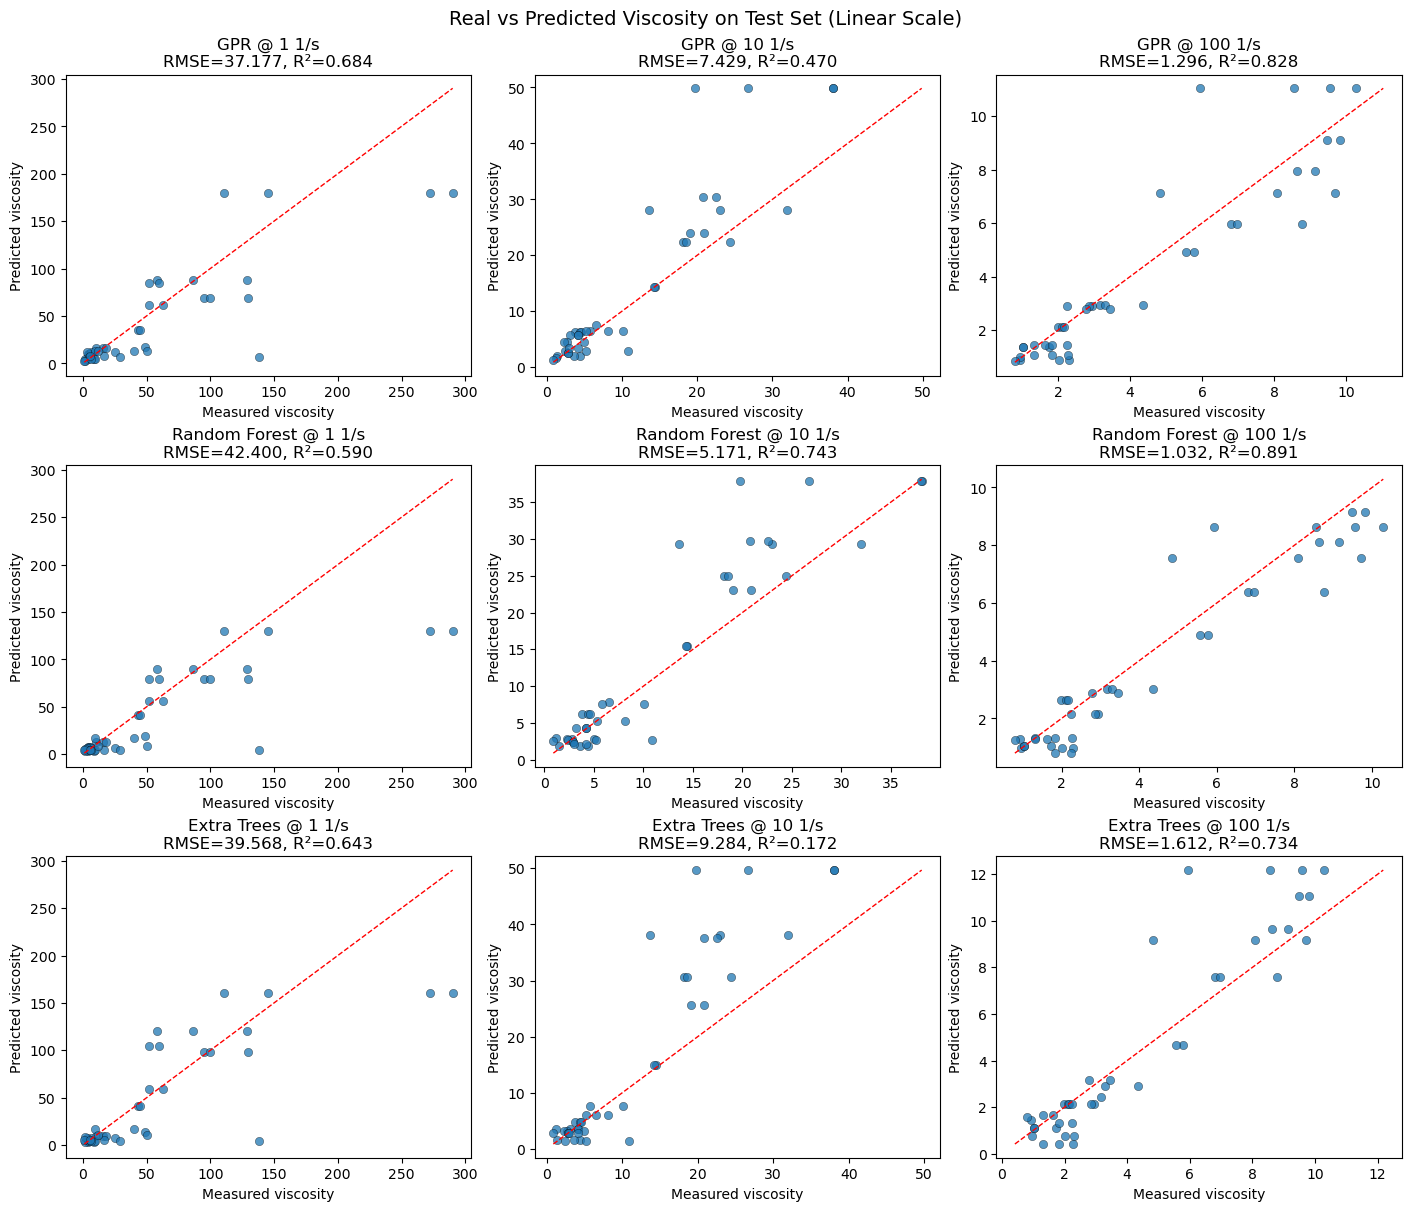

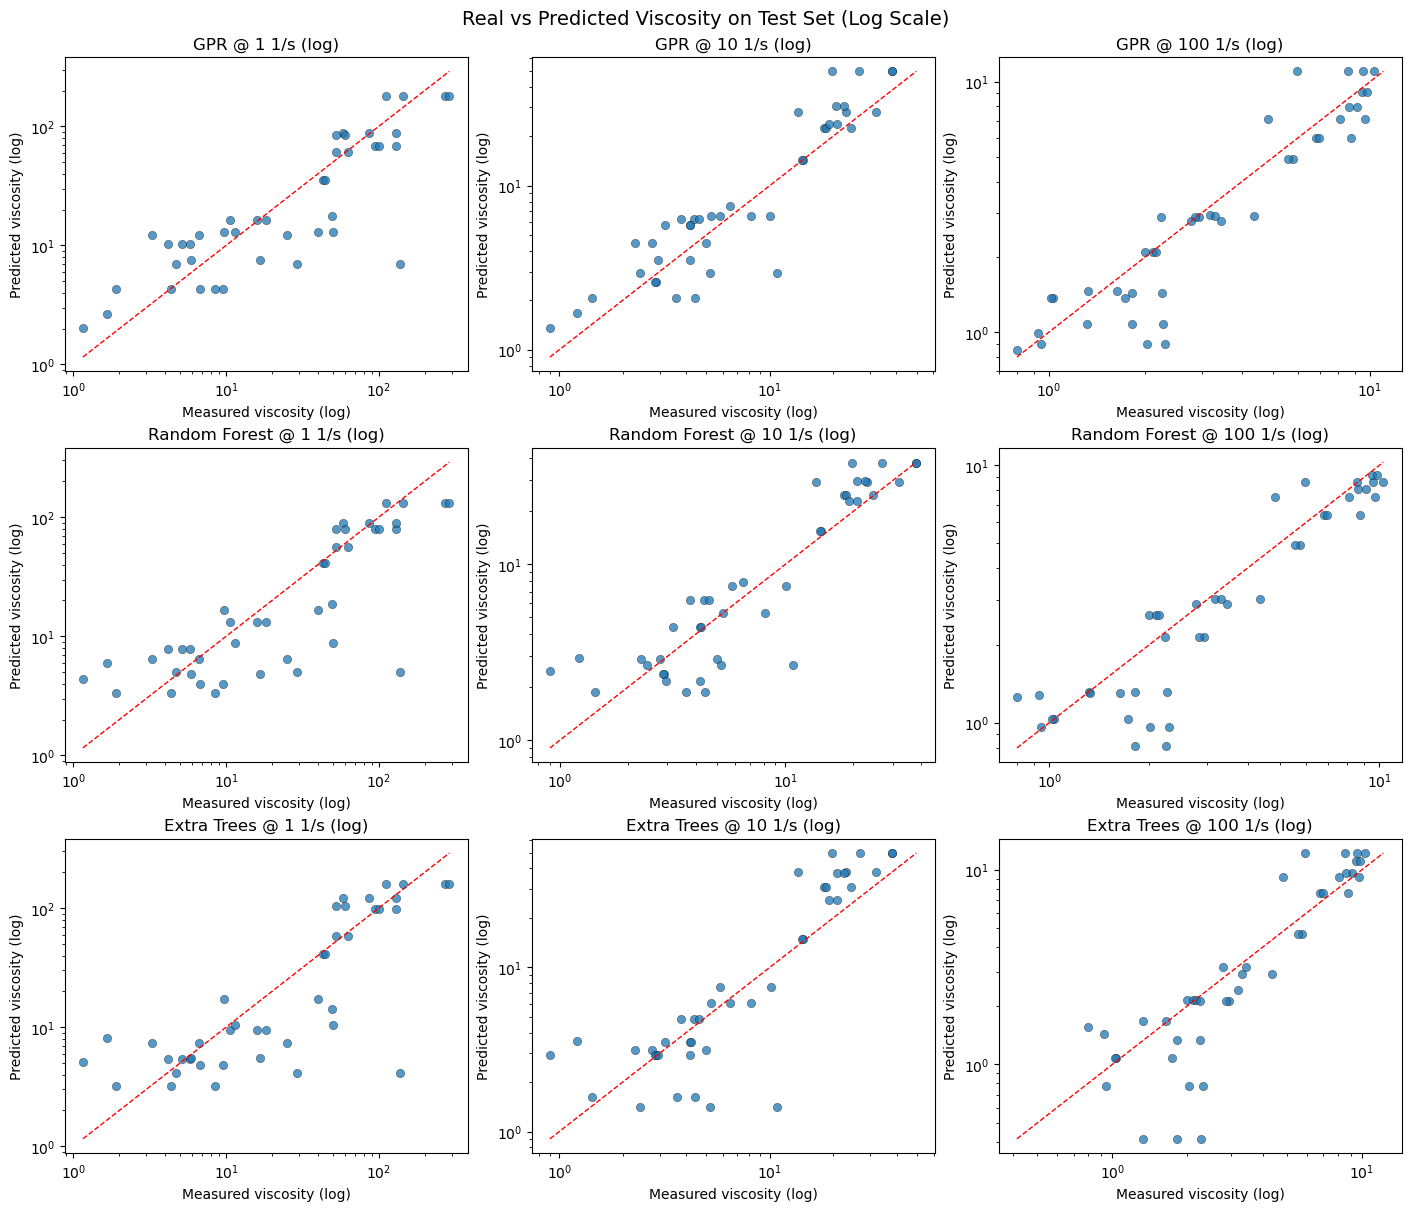

Viscosity Reconstruction Summary (Test Set):


,Model,ShearRate_1_per_s,RMSE,R2
6,Extra Trees,1,39.5677,0.6426
7,Extra Trees,10,9.2841,0.1724
8,Extra Trees,100,1.6125,0.7339
0,GPR,1,37.1767,0.6845
1,GPR,10,7.4294,0.4701
2,GPR,100,1.2956,0.8282
3,Random Forest,1,42.3996,0.5896
4,Random Forest,10,5.1711,0.7433
5,Random Forest,100,1.0324,0.8909


In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Build test dataframe with measured viscosities via row_index mapping
test_rows = df.loc[physics_test['row_index'], target_cols].copy().reset_index(drop=True)

# Predict CY parameters on test set (models output log-parameters)
pred_gpr = pd.DataFrame({p: np.exp(gpr_models[p].predict(X_test_scaled)) for p in ml_target_cols})
pred_rf = pd.DataFrame({p: np.exp(rf_models[p].predict(X_test_encoded)) for p in ml_target_cols})
pred_et = pd.DataFrame({p: np.exp(et_models[p].predict(X_test_encoded)) for p in ml_target_cols})

# Fill locked parameters if needed for viscosity reconstruction
for locked_col in ['eta_inf', 'a']:
    if locked_col not in pred_gpr.columns:
        pred_gpr[locked_col] = physics_test[locked_col].values
        pred_rf[locked_col] = physics_test[locked_col].values
        pred_et[locked_col] = physics_test[locked_col].values

# Ensure full CY parameter order
param_order = ['eta_0', 'eta_inf', 'lambda_time', 'n', 'a']
pred_gpr = pred_gpr[param_order]
pred_rf = pred_rf[param_order]
pred_et = pred_et[param_order]

model_preds = {
    'GPR': pred_gpr,
    'Random Forest': pred_rf,
    'Extra Trees': pred_et,
}

rate_to_col = {
    1.0: 'Viscosity_at_shear_rate_1_1/s',
    10.0: 'Viscosity_at_shear_rate_10_1/s',
    100.0: 'Viscosity_at_shear_rate_100_1/s',
}

metrics_records = []

# Linear-scale scatter plots
fig, axes = plt.subplots(3, 3, figsize=(14, 12), constrained_layout=True)

for row_i, (model_name, pred_params) in enumerate(model_preds.items()):
    for col_i, shear_rate in enumerate([1.0, 10.0, 100.0]):
        ax = axes[row_i, col_i]

        y_true = test_rows[rate_to_col[shear_rate]].values
        y_pred = carreau_yasuda(
            shear_rate,
            pred_params['eta_0'].values,
            pred_params['eta_inf'].values,
            pred_params['lambda_time'].values,
            pred_params['n'].values,
            pred_params['a'].values,
        )

        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        metrics_records.append(
            {
                'Model': model_name,
                'ShearRate_1_per_s': int(shear_rate),
                'RMSE': rmse,
                'R2': r2,
            }
        )

        ax.scatter(y_true, y_pred, alpha=0.75, edgecolor='k', linewidth=0.3)
        min_v = min(y_true.min(), y_pred.min())
        max_v = max(y_true.max(), y_pred.max())
        ax.plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=1)

        ax.set_title(f"{model_name} @ {int(shear_rate)} 1/s\nRMSE={rmse:.3f}, R²={r2:.3f}")
        ax.set_xlabel('Measured viscosity')
        ax.set_ylabel('Predicted viscosity')

plt.suptitle('Real vs Predicted Viscosity on Test Set (Linear Scale)', fontsize=14)
plt.show()

# Log-scale scatter plots (only positive values)
fig, axes = plt.subplots(3, 3, figsize=(14, 12), constrained_layout=True)

for row_i, (model_name, pred_params) in enumerate(model_preds.items()):
    for col_i, shear_rate in enumerate([1.0, 10.0, 100.0]):
        ax = axes[row_i, col_i]

        y_true = test_rows[rate_to_col[shear_rate]].values
        y_pred = carreau_yasuda(
            shear_rate,
            pred_params['eta_0'].values,
            pred_params['eta_inf'].values,
            pred_params['lambda_time'].values,
            pred_params['n'].values,
            pred_params['a'].values,
        )

        pos_mask = (y_true > 0) & (y_pred > 0)
        y_true_pos = y_true[pos_mask]
        y_pred_pos = y_pred[pos_mask]

        ax.scatter(y_true_pos, y_pred_pos, alpha=0.75, edgecolor='k', linewidth=0.3)

        if len(y_true_pos) > 0:
            min_v = min(y_true_pos.min(), y_pred_pos.min())
            max_v = max(y_true_pos.max(), y_pred_pos.max())
            ax.plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=1)

        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_title(f"{model_name} @ {int(shear_rate)} 1/s (log)")
        ax.set_xlabel('Measured viscosity (log)')
        ax.set_ylabel('Predicted viscosity (log)')

plt.suptitle('Real vs Predicted Viscosity on Test Set (Log Scale)', fontsize=14)
plt.show()

# Compact summary table under the plots
viscosity_summary = pd.DataFrame(metrics_records).sort_values(['Model', 'ShearRate_1_per_s'])
print('Viscosity Reconstruction Summary (Test Set):')
display(viscosity_summary.round(4))

### 8.6 Basic, Separated Ablation Studies

Keep factors separate and test one change at a time on the same leakage-safe split:

1. Engineered features study:
- Base features vs Base + chemistry ratios
- Kernel fixed (Matérn $\nu=2.5$ + WhiteKernel)
- Raw targets

2. Kernel study:
- RBF + WhiteKernel vs Matérn $\nu=2.5$ + WhiteKernel vs Matérn $\nu=1.5$ + WhiteKernel
- Features fixed (Base + chemistry ratios)
- Raw targets

3. Target-transform study:
- Raw targets vs Log targets
- Features fixed (Base + chemistry ratios)
- Kernel fixed (Matérn $\nu=2.5$ + WhiteKernel)

Report test $R^2$ for $\lambda$ and $n$ to isolate each effect cleanly.

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, ConstantKernel as C, WhiteKernel
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.metrics import r2_score

# Fixed feature groups
base_feature_cols = [
    'Dispersent_Type', 'Solid_Content_pct', 'Solid_Additive_pct',
    'NMC_pct', 'C65_pct', 'KS6L_pct', 'PVDF_pct', 'Source_Batch',
]
ratio_feature_cols = ['Solid_to_Liquid_Ratio', 'Binder_to_Active_Ratio']

# Consistent target definition
candidate_target_cols = ['eta_0', 'eta_inf', 'lambda_time', 'n', 'a']
if USE_LOCKED_PARAMETER_ABLATION:
    locked_target_cols = [c for c in candidate_target_cols if physics_df[c].nunique(dropna=False) <= 1]
else:
    locked_target_cols = []
ml_target_cols_study = [c for c in candidate_target_cols if c not in locked_target_cols]

def build_gpr_kernel(kernel_name):
    if kernel_name == 'RBF':
        return C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) + WhiteKernel(noise_level=0.05, noise_level_bounds=(1e-6, 1e1))
    if kernel_name == 'Matern_1.5':
        return C(1.0, (1e-3, 1e3)) * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=1.5) + WhiteKernel(noise_level=0.05, noise_level_bounds=(1e-6, 1e1))
    # Default: Matern_2.5
    return C(1.0, (1e-3, 1e3)) * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5) + WhiteKernel(noise_level=0.05, noise_level_bounds=(1e-6, 1e1))

def run_single_setting(setting_name, use_ratios, kernel_name, use_log_targets):
    feat_cols = base_feature_cols + (ratio_feature_cols if use_ratios else [])

    Xtr = physics_train[feat_cols].copy()
    Xte = physics_test[feat_cols].copy()
    ytr_raw = physics_train[ml_target_cols_study].copy()
    yte_raw = physics_test[ml_target_cols_study].copy()

    ytr_model = np.log(ytr_raw.clip(lower=1e-8)) if use_log_targets else ytr_raw.copy()

    # Encode categoricals
    Xtr_enc = pd.get_dummies(Xtr, columns=['Dispersent_Type', 'Source_Batch'], drop_first=False)
    Xte_enc = pd.get_dummies(Xte, columns=['Dispersent_Type', 'Source_Batch'], drop_first=False)

    missing_cols = set(Xtr_enc.columns) - set(Xte_enc.columns)
    for col in missing_cols:
        Xte_enc[col] = 0
    Xte_enc = Xte_enc[Xtr_enc.columns]

    Xtr_enc = Xtr_enc.fillna(Xtr_enc.mean())
    Xte_enc = Xte_enc.fillna(Xtr_enc.mean())

    scaler_local = StandardScaler()
    Xtr_scaled = scaler_local.fit_transform(Xtr_enc)
    Xte_scaled = scaler_local.transform(Xte_enc)

    gpr_test_r2_local = {}
    rf_test_r2_local = {}
    et_test_r2_local = {}

    for target_param in ml_target_cols_study:
        # GPR
        kernel = build_gpr_kernel(kernel_name)
        gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5, alpha=1e-8, random_state=42)
        gpr.fit(Xtr_scaled, ytr_model[target_param])
        gpr_pred = gpr.predict(Xte_scaled)

        # RF
        rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
        rf.fit(Xtr_enc, ytr_model[target_param])
        rf_pred = rf.predict(Xte_enc)

        # ET
        et = ExtraTreesRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
        et.fit(Xtr_enc, ytr_model[target_param])
        et_pred = et.predict(Xte_enc)

        if use_log_targets:
            gpr_pred = np.exp(gpr_pred)
            rf_pred = np.exp(rf_pred)
            et_pred = np.exp(et_pred)

        gpr_test_r2_local[target_param] = r2_score(yte_raw[target_param], gpr_pred)
        rf_test_r2_local[target_param] = r2_score(yte_raw[target_param], rf_pred)
        et_test_r2_local[target_param] = r2_score(yte_raw[target_param], et_pred)

    return {
        'Setting': setting_name,
        'GPR_lambda_Test_R2': gpr_test_r2_local.get('lambda_time', np.nan),
        'RF_lambda_Test_R2': rf_test_r2_local.get('lambda_time', np.nan),
        'ET_lambda_Test_R2': et_test_r2_local.get('lambda_time', np.nan),
        'GPR_n_Test_R2': gpr_test_r2_local.get('n', np.nan),
        'RF_n_Test_R2': rf_test_r2_local.get('n', np.nan),
        'ET_n_Test_R2': et_test_r2_local.get('n', np.nan),
    }

# ------------------------------------------------------------------
# 1) Engineered features study (kernel fixed, raw targets)
# ------------------------------------------------------------------
feature_results = [
    run_single_setting('Base features', use_ratios=False, kernel_name='Matern_2.5', use_log_targets=False),
    run_single_setting('Base + ratios', use_ratios=True, kernel_name='Matern_2.5', use_log_targets=False),
]
feature_df = pd.DataFrame(feature_results)
feature_baseline = feature_df.iloc[0]
for col in ['GPR_lambda_Test_R2', 'RF_lambda_Test_R2', 'ET_lambda_Test_R2', 'GPR_n_Test_R2', 'RF_n_Test_R2', 'ET_n_Test_R2']:
    feature_df[f'{col}_Delta'] = feature_df[col] - feature_baseline[col]

print('Ablation 1: Engineered Features (Kernel=Matérn 2.5, Raw Targets)')
display(feature_df.round(4))

# ------------------------------------------------------------------
# 2) Kernel study (features fixed with ratios, raw targets)
# ------------------------------------------------------------------
kernel_results = [
    run_single_setting('RBF + White', use_ratios=True, kernel_name='RBF', use_log_targets=False),
    run_single_setting('Matern 2.5 + White', use_ratios=True, kernel_name='Matern_2.5', use_log_targets=False),
    run_single_setting('Matern 1.5 + White', use_ratios=True, kernel_name='Matern_1.5', use_log_targets=False),
]
kernel_df = pd.DataFrame(kernel_results)
kernel_baseline = kernel_df.iloc[0]
for col in ['GPR_lambda_Test_R2', 'RF_lambda_Test_R2', 'ET_lambda_Test_R2', 'GPR_n_Test_R2', 'RF_n_Test_R2', 'ET_n_Test_R2']:
    kernel_df[f'{col}_Delta_vs_RBF'] = kernel_df[col] - kernel_baseline[col]

print('\nAblation 2: Kernel Choice (Features=Base+Ratios, Raw Targets)')
display(kernel_df.round(4))

# ------------------------------------------------------------------
# 3) Target transform study (features fixed with ratios, kernel fixed)
# ------------------------------------------------------------------
transform_results = [
    run_single_setting('Raw targets', use_ratios=True, kernel_name='Matern_2.5', use_log_targets=False),
    run_single_setting('Log targets', use_ratios=True, kernel_name='Matern_2.5', use_log_targets=True),
]
transform_df = pd.DataFrame(transform_results)
transform_baseline = transform_df.iloc[0]
for col in ['GPR_lambda_Test_R2', 'RF_lambda_Test_R2', 'ET_lambda_Test_R2', 'GPR_n_Test_R2', 'RF_n_Test_R2', 'ET_n_Test_R2']:
    transform_df[f'{col}_Delta'] = transform_df[col] - transform_baseline[col]

print('\nAblation 3: Target Transform (Features=Base+Ratios, Kernel=Matérn 2.5)')
display(transform_df.round(4))

# Quick recommendation summary (based on lambda and n)
print('\nBest settings by metric (GPR):')
print(f"  lambda - features study : {feature_df.loc[feature_df['GPR_lambda_Test_R2'].idxmax(), 'Setting']}")
print(f"  lambda - kernel study   : {kernel_df.loc[kernel_df['GPR_lambda_Test_R2'].idxmax(), 'Setting']}")
print(f"  lambda - transform study: {transform_df.loc[transform_df['GPR_lambda_Test_R2'].idxmax(), 'Setting']}")
print(f"  n      - features study : {feature_df.loc[feature_df['GPR_n_Test_R2'].idxmax(), 'Setting']}")
print(f"  n      - kernel study   : {kernel_df.loc[kernel_df['GPR_n_Test_R2'].idxmax(), 'Setting']}")
print(f"  n      - transform study: {transform_df.loc[transform_df['GPR_n_Test_R2'].idxmax(), 'Setting']}")

Ablation 1: Engineered Features (Kernel=Matérn 2.5, Raw Targets)


,Setting,GPR_lambda_Test_R2,RF_lambda_Test_R2,ET_lambda_Test_R2,GPR_n_Test_R2,RF_n_Test_R2,ET_n_Test_R2,GPR_lambda_Test_R2_Delta,RF_lambda_Test_R2_Delta,ET_lambda_Test_R2_Delta,GPR_n_Test_R2_Delta,RF_n_Test_R2_Delta,ET_n_Test_R2_Delta
0,Base features,0.1652,0.1034,-0.1047,0.5234,0.3879,0.4988,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,Base + ratios,0.1401,0.1054,-0.1315,0.5108,0.3965,0.4602,-0.0251,0.0021,-0.0269,-0.0125,0.0086,-0.0386



Ablation 2: Kernel Choice (Features=Base+Ratios, Raw Targets)


,Setting,GPR_lambda_Test_R2,RF_lambda_Test_R2,ET_lambda_Test_R2,GPR_n_Test_R2,RF_n_Test_R2,ET_n_Test_R2,GPR_lambda_Test_R2_Delta_vs_RBF,RF_lambda_Test_R2_Delta_vs_RBF,ET_lambda_Test_R2_Delta_vs_RBF,GPR_n_Test_R2_Delta_vs_RBF,RF_n_Test_R2_Delta_vs_RBF,ET_n_Test_R2_Delta_vs_RBF
0,RBF + White,0.1989,0.1054,-0.1315,0.5089,0.3965,0.4602,0.0000,0.0,0.0,0.0000,0.0,0.0
1,Matern 2.5 + White,0.1401,0.1054,-0.1315,0.5108,0.3965,0.4602,-0.0587,-0.0,-0.0,0.0020,0.0,0.0
2,Matern 1.5 + White,0.0887,0.1054,-0.1315,0.5120,0.3965,0.4602,-0.1102,-0.0,0.0,0.0031,0.0,0.0



Ablation 3: Target Transform (Features=Base+Ratios, Kernel=Matérn 2.5)


,Setting,GPR_lambda_Test_R2,RF_lambda_Test_R2,ET_lambda_Test_R2,GPR_n_Test_R2,RF_n_Test_R2,ET_n_Test_R2,GPR_lambda_Test_R2_Delta,RF_lambda_Test_R2_Delta,ET_lambda_Test_R2_Delta,GPR_n_Test_R2_Delta,RF_n_Test_R2_Delta,ET_n_Test_R2_Delta
0,Raw targets,0.1401,0.1054,-0.1315,0.5108,0.3965,0.4602,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,Log targets,0.0315,0.1078,-0.3564,0.5061,0.4569,0.5040,-0.1086,0.0023,-0.2248,-0.0048,0.0604,0.0439



Best settings by metric (GPR):
  lambda - features study : Base features
  lambda - kernel study   : RBF + White
  lambda - transform study: Raw targets
  n      - features study : Base features
  n      - kernel study   : Matern 1.5 + White
  n      - transform study: Raw targets
